In [1]:
import os
import yaml
import errno
import subprocess
import ROOT
import json
import pyarrow as pa
import pyarrow.parquet as pq
from scipy.stats import poisson
import glob
import numpy as np
import pandas as pd 
from scipy.optimize import minimize, curve_fit
import matplotlib.pyplot as plt
import mplhep as hep
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle



production_XS = {
    "GluGluHtoGG": 51.96,
    "GluGluHto2G": 51.96,
    "VBFHtoGG": 4.067,
    "VBFHto2G": 4.067,
    "VHtoGG": 2.3781,
    "VHto2G": 2.3781,
    "ttHtoGG": 0.5638,
    "ttHto2G": 0.5638,
    "bbHtoGG": 0.49,
    "bbHto2G": 0.49,
}

lumiMap = {
    '2016':36.33, 
    '2018':59.83, 
    'combined':137.65, 
    'merged':137.65,
    '2022preEE':8.00,
    '2022postEE':26.70,
    '2022': 34.7,
    '2023preBPix': 17.8,
    '2023postBPix': 9.5,
    '2023': 27.3
}


In [ ]:
# Importing translation dictionary
translationFilePath = "/work/niharrin/t35/CMSSW_14_1_0_pre4/src/flashggFinalFit/Replicas/corr_matrix/translation.json"
with open(translationFilePath) as translationFile:
    translation = json.load(translationFile)

In [10]:
# main_parquet_dir = '/pnfs/psi.ch/cms/trivcat/store/user/niharrin/ntuples/midRun3/samples/2025_07_17_powheg/signal'
# powheg_main_parquet_dir = '/pnfs/psi.ch/cms/trivcat/store/user/niharrin/ntuples/midRun3/samples/2025_09_06_powheg/signal'
powheg_main_parquet_dir = '/pnfs/psi.ch/cms/trivcat/store/user/niharrin/ntuples/midRun3/samples/2025_09_22/intermediateRun3NTuples_powheg/signal/GluGluHtoGG_M-125_2023preBPix'
# mc_main_parquet_dir = '/pnfs/psi.ch/cms/trivcat/store/user/niharrin/ntuples/midRun3/samples/2025_06_12/intermediateRun3/signal/GluGluHtoGG_M-125_2023postBPix'
mc_main_parquet_dir = '/pnfs/psi.ch/cms/trivcat/store/user/niharrin/ntuples/midRun3/samples/2025_09_16/intermediateRun3/signal/GluGluHtoGG_M-125_2023postBPix'

# powheg_proc_folders = glob.glob(os.path.join(powheg_main_parquet_dir, "*125*"))
powheg_proc_folders = glob.glob(os.path.join(powheg_main_parquet_dir))

In [ ]:
powheg_dfs = {}

for kin_variable in ["PTH", "NJ", "rapidity"]:
    
    powheg_dfs[kin_variable] = {}

    cat_dict_path = os.path.join("/work/niharrin/t35/CMSSW_14_1_0_pre4/src/flashggFinalFit/Replicas/corr_matrix/corrMatrixDirectlyWithNTuples/cats", f"{kin_variable}_MC.json")
    if not os.path.exists(cat_dict_path):
        print(f"Category dictionary {cat_dict_path} does not exist. Check path in law_replica.py. Exiting...")
        exit(1)
    else:
        with open(cat_dict_path) as pf:
            cat_dict = json.load(pf)

    for powheg_proc_folder in powheg_proc_folders:
        # Load the parquet files for the current process
        powheg_proc_parquet_files = glob.glob(os.path.join(powheg_proc_folder, "nominal", "*.parquet"))
        
        process_name = powheg_proc_parquet_files[0].split("/")[-3].split("_")[0]
                
        era = powheg_proc_parquet_files[0].split("/")[-3].split("_")[-1]
        
        sum_genw_beforesel = 0
        for i in range(len(powheg_proc_parquet_files)):
            sum_genw_beforesel += float(pq.read_table(powheg_proc_parquet_files[i]).schema.metadata[b'sum_genw_presel'])

                
        columns_to_load = ["mass", "weight", "genWeight", "pt", "PTJ0", "NJ", "DPhiJ0J1", "rapidity", "lead_mvaID", "sublead_mvaID", "sigma_m_over_m_corr_smeared_decorr", "first_jet_eta"]
        
        df = pd.concat((pd.read_parquet(f, columns=columns_to_load) for f in powheg_proc_parquet_files), ignore_index=True)
        
        df["weight_norm"] = df["weight"] / sum_genw_beforesel
        
        # Now merge the procs per category
        for cat in cat_dict:
            try:
                query_str = " and ".join(
                    f"{col} {op} {val}" for col, op, val in cat_dict[cat]["cat_filter"]
                )
            except:
                # Have a variable using absolute values.
                query_str = "("
                for k, set_of_conditions in enumerate(cat_dict[cat]["cat_filter"]):
                    if k > 0:
                        query_str += ") or ("
                    query_str += " and ".join(
                        f"{col} {op} {val}" for col, op, val in set_of_conditions
                    )
                query_str += ")"
            # Merge the replicas for the current category
            binned_df = pd.concat([df.query(query_str)], ignore_index=True)
            
            powheg_dfs[kin_variable][cat] = binned_df

In [15]:
# madgraph_dfs = {}

# for kin_variable in ["PTH", "NJ", "rapidity"]:
    
#     madgraph_dfs[kin_variable] = {}

#     cat_dict_path = os.path.join("/work/niharrin/t35/CMSSW_14_1_0_pre4/src/flashggFinalFit/Replicas/corr_matrix/corrMatrixDirectlyWithNTuples/cats", f"{kin_variable}_MC.json")
#     if not os.path.exists(cat_dict_path):
#         print(f"Category dictionary {cat_dict_path} does not exist. Check path in law_replica.py. Exiting...")
#         exit(1)
#     else:
#         with open(cat_dict_path) as pf:
#             cat_dict = json.load(pf)

#     # Load the parquet files for the current process
#     mg_proc_parquet_files = glob.glob(os.path.join(mc_main_parquet_dir, "nominal", "*.parquet"))

#     process_name = mg_proc_parquet_files[0].split("/")[-3].split("_")[0]
            
#     era = mg_proc_parquet_files[0].split("/")[-3].split("_")[-1]

#     mg_sum_genw_beforesel = 0
#     for i in range(len(mg_proc_parquet_files)):
#         mg_sum_genw_beforesel += float(pq.read_table(mg_proc_parquet_files[i]).schema.metadata[b'sum_genw_presel'])

            
#     columns_to_load = ["mass", "weight", "genWeight", "pt", "PTJ0", "NJ", "DPhiJ0J1", "rapidity", "lead_mvaID", "sublead_mvaID", "sigma_m_over_m_corr_smeared_decorr"]

#     df = pd.concat((pd.read_parquet(f, columns=columns_to_load) for f in mg_proc_parquet_files), ignore_index=True)

#     df["weight_norm"] = df["weight"] / mg_sum_genw_beforesel

#     # Now merge the procs per category
#     for cat in cat_dict:
#         try:
#             query_str = " and ".join(
#                 f"{col} {op} {val}" for col, op, val in cat_dict[cat]["cat_filter"]
#             )
#         except:
#             # Have a variable using absolute values.
#             query_str = "("
#             for k, set_of_conditions in enumerate(cat_dict[cat]["cat_filter"]):
#                 if k > 0:
#                     query_str += ") or ("
#                 query_str += " and ".join(
#                     f"{col} {op} {val}" for col, op, val in set_of_conditions
#                 )
#             query_str += ")"
#         # Merge the replicas for the current category
#         binned_df = pd.concat([df.query(query_str)], ignore_index=False)
        
#         madgraph_dfs[kin_variable][cat] = binned_df


In [47]:
madgraph_dfs = {}



PTH_cat_dict_path = os.path.join("/work/niharrin/t35/CMSSW_14_1_0_pre4/src/flashggFinalFit/Replicas/corr_matrix/corrMatrixDirectlyWithNTuples/cats", f"PTH_MC.json")
rapidity_cat_dict_path = os.path.join("/work/niharrin/t35/CMSSW_14_1_0_pre4/src/flashggFinalFit/Replicas/corr_matrix/corrMatrixDirectlyWithNTuples/cats", f"rapidity_MC.json")
NJ_cat_dict_path = os.path.join("/work/niharrin/t35/CMSSW_14_1_0_pre4/src/flashggFinalFit/Replicas/corr_matrix/corrMatrixDirectlyWithNTuples/cats", f"NJ_MC.json")
PTJ0_cat_dict_path = os.path.join("/work/niharrin/t35/CMSSW_14_1_0_pre4/src/flashggFinalFit/Replicas/corr_matrix/corrMatrixDirectlyWithNTuples/cats", f"PTJ0_MC.json")
DPhiJ0J1_cat_dict_path = os.path.join("/work/niharrin/t35/CMSSW_14_1_0_pre4/src/flashggFinalFit/Replicas/corr_matrix/corrMatrixDirectlyWithNTuples/cats", f"DPhiJ0J1_MC.json")

with open(PTH_cat_dict_path) as pf:
    PTH_cat_dict = json.load(pf)

with open(rapidity_cat_dict_path) as pf:
    rapidity_cat_dict = json.load(pf)

with open(NJ_cat_dict_path) as pf:
    NJ_cat_dict = json.load(pf)

with open(PTJ0_cat_dict_path) as pf:
    PTJ0_cat_dict = json.load(pf)

with open(DPhiJ0J1_cat_dict_path) as pf:
    DPhiJ0J1_cat_dict = json.load(pf)

# Load the parquet files for the current process
mg_proc_parquet_files = glob.glob(os.path.join(mc_main_parquet_dir, "nominal", "*.parquet"))

process_name = mg_proc_parquet_files[0].split("/")[-3].split("_")[0]
        
era = mg_proc_parquet_files[0].split("/")[-3].split("_")[-1]

mg_sum_genw_beforesel = 0
for i in range(len(mg_proc_parquet_files)):
    mg_sum_genw_beforesel += float(pq.read_table(mg_proc_parquet_files[i]).schema.metadata[b'sum_genw_presel'])

        
columns_to_load = ["mass", "weight", "genWeight", "pt", "PTJ0", "NJ", "DPhiJ0J1", "rapidity", "lead_mvaID", "sublead_mvaID", "sigma_m_over_m_corr_smeared_decorr", "first_jet_eta"]

df = pd.concat((pd.read_parquet(f, columns=columns_to_load) for f in mg_proc_parquet_files), ignore_index=True)

df["weight_norm"] = df["weight"] / mg_sum_genw_beforesel

In [48]:
df[(df["NJ"] == 0) & (df["first_jet_eta"] != -999)][["NJ", "first_jet_eta", "PTJ0"]].max()

NJ                0.000000
first_jet_eta     2.499512
PTJ0             29.999929
dtype: float64

In [ ]:
unique_dict_combinations = [[PTH_cat_dict, PTH_cat_dict], 
                       [PTH_cat_dict, rapidity_cat_dict], 
                       [PTH_cat_dict, PTJ0_cat_dict], 
                       [rapidity_cat_dict, rapidity_cat_dict], 
                       [rapidity_cat_dict, PTJ0_cat_dict], 
                       [PTJ0_cat_dict, PTJ0_cat_dict],
                       [NJ_cat_dict, NJ_cat_dict],
                       [NJ_cat_dict, PTJ0_cat_dict],
                       [NJ_cat_dict, rapidity_cat_dict],
                       [NJ_cat_dict, PTH_cat_dict],
                       [DPhiJ0J1_cat_dict, DPhiJ0J1_cat_dict],
                       [DPhiJ0J1_cat_dict, PTJ0_cat_dict],
                       [DPhiJ0J1_cat_dict, NJ_cat_dict],
                       [DPhiJ0J1_cat_dict, rapidity_cat_dict],
                       [DPhiJ0J1_cat_dict, PTH_cat_dict]]

unique_variable_combinations = [["pt", "pt"], 
                       ["pt", "rapidity"], 
                       ["pt", "PTJ0"], 
                       ["rapidity", "rapidity"], 
                       ["rapidity", "PTJ0"], 
                       ["PTJ0", "PTJ0"],
                       ["NJ", "NJ"],
                       ["NJ", "PTJ0"],
                       ["NJ", "rapidity"],
                       ["NJ", "pt"],
                       ["DPhiJ0J1", "DPhiJ0J1"],
                       ["DPhiJ0J1", "PTJ0"],
                       ["DPhiJ0J1", "NJ"],
                       ["DPhiJ0J1", "rapidity"],
                       ["DPhiJ0J1", "pt"]]

unique_keys_list = []

for dict_pair in unique_dict_combinations:
    for d in dict_pair:
        for k in d.keys():
            if k not in unique_keys_list:  # preserve first-seen order
                unique_keys_list.append(k)

corr_df = pd.DataFrame(index=unique_keys_list, columns=unique_keys_list, dtype=float)

# exclude -999 values (including them does not make any sense)
df = df[(df["PTJ0"] != -999) & (df["NJ"] != -999) & (df["rapidity"] != -999) & (df["pt"] != -999) & (df["DPhiJ0J1"] != -999)]



['RECO_PTH_0p0_15p0', 'RECO_PTH_15p0_30p0', 'RECO_PTH_30p0_45p0', 'RECO_PTH_45p0_80p0', 'RECO_PTH_80p0_120p0', 'RECO_PTH_120p0_200p0', 'RECO_PTH_200p0_350p0', 'RECO_PTH_350p0_10000p0', 'RECO_rapidity_0p0_0p15', 'RECO_rapidity_0p15_0p3', 'RECO_rapidity_0p3_0p6', 'RECO_rapidity_0p6_0p9', 'RECO_rapidity_0p9_2p5', 'RECO_PTJ0_0p0_30p0', 'RECO_PTJ0_30p0_75p0', 'RECO_PTJ0_75p0_120p0', 'RECO_PTJ0_120p0_200p0', 'RECO_PTJ0_200p0_10000p0', 'RECO_NJ_0p0_1p0', 'RECO_NJ_1p0_2p0', 'RECO_NJ_2p0_3p0', 'RECO_NJ_3p0_100p0', 'RECO_DPhiJ0J1_m3p1416_m2p0944', 'RECO_DPhiJ0J1_m2p0944_m1p0472', 'RECO_DPhiJ0J1_m1p0472_0p0', 'RECO_DPhiJ0J1_0p0_1p0472', 'RECO_DPhiJ0J1_1p0472_2p0944', 'RECO_DPhiJ0J1_2p0944_3p1416']


In [71]:

correlation_matrices = []

for i, cat_dicts in enumerate(unique_dict_combinations):
    cat_dict_1, cat_dict_2 = cat_dicts
    variable_1, variable_2 = unique_variable_combinations[i]
    
    # corr_df = pd.DataFrame(index=cat_dict_2.keys(), columns=cat_dict_1.keys(), dtype=float)
    
    for cat_1 in cat_dict_1:
        try:
            query_str_1 = " and ".join(
                f"{col} {op} {val}" for col, op, val in cat_dict_1[cat_1]["cat_filter"]
            )
        except:
            # Have a variable using absolute values.
            query_str_1 = "("
            for k, set_of_conditions in enumerate(cat_dict_1[cat_1]["cat_filter"]):
                if k > 0:
                    query_str_1 += ") or ("
                query_str_1 += " and ".join(
                    f"{col} {op} {val}" for col, op, val in set_of_conditions
                )
            query_str_1 += ")"
    
        for cat_2 in cat_dict_2:
            try:
                query_str_2 = " and ".join(
                    f"{col} {op} {val}" for col, op, val in cat_dict_2[cat_2]["cat_filter"]
                )
            except:
                # Have a variable using absolute values.
                query_str_2 = "("
                for k, set_of_conditions in enumerate(cat_dict_2[cat_2]["cat_filter"]):
                    if k > 0:
                        query_str_2 += ") or ("
                    query_str_2 += " and ".join(
                        f"{col} {op} {val}" for col, op, val in set_of_conditions
                    )
                query_str_2 += ")"
        
            query_str = f"({query_str_1}) and ({query_str_2})"
            # print(f"Calculating correlation between {variable_1} in category {cat_1} and {variable_2} in category {cat_2} using query: {query_str}")
            # Merge the replicas for the current category
            binned_df = pd.concat([df.query(query_str)], ignore_index=False)
            
            
            # Compute the correlation between variable_1 and variable_2 in binned_df if needed
            correlation = binned_df[variable_1].corr(binned_df[variable_2], method="pearson")
            # print(f"Correlation between {variable_1} and {variable_2} in categories {cat_1} and {cat_2}: {correlation} using {len(binned_df)} events")

            # if pd.isna(correlation):
            #     # A correlation with NaN inside does not make any sense
            #     print(pd.isna(binned_df[variable_1]).sum())
            #     correlation = 0.0
            
            if (len(binned_df[variable_1]) < 100) | (len(binned_df[variable_2]) < 100):
                # The correlation is not reliable with too few events
                correlation = 0.0
            
            if "RECO_NJ_0p0_1p0" in [cat_1, cat_2]:
                # This is expected since PTJ0 is always < 30 in this category
                print(f"Bins: {cat_1}, {cat_2}")
                print(correlation)
                print(query_str)
                print(binned_df)
                
                # plt.figure(figsize=(12,12))
                # plt.scatter(binned_df[variable_1], binned_df[variable_2], alpha=0.5)
                # plt.xlabel(f"{variable_1} in {cat_1}")
                # plt.ylabel(f"{variable_2} in {cat_2}")
                # plt.title(f"Correlation: {correlation:.3f} ({len(binned_df)} events)")
                # plt.grid(True)
                # plt.axhline(0, color='red', linestyle='--', linewidth=1)
                # plt.axvline(0, color='red', linestyle='--', linewidth=1)
                # plt.show()
            
            # Plot the correlation in a scatter plot
            # plt.figure(figsize=(12,12))
            # plt.scatter(binned_df[variable_1], binned_df[variable_2], alpha=0.5)
            # plt.xlabel(f"{variable_1} in {cat_1}")
            # plt.ylabel(f"{variable_2} in {cat_2}")
            # plt.title(f"Correlation: {correlation:.3f} ({len(binned_df)} events)")
            # plt.grid(True)
            # plt.axhline(0, color='red', linestyle='--', linewidth=1)
            # plt.axvline(0, color='red', linestyle='--', linewidth=1)
            # plt.show()
            # # plt.savefig(f"correlation_{variable_1}_{cat_1}_vs_{variable_2}_{cat_2}.png")
            # # plt.close()
            
            corr_df.loc[cat_2, cat_1] = correlation
            corr_df.loc[cat_1, cat_2] = correlation
    
    correlation_matrices.append(corr_df)


/work/niharrin/miniforge3/envs/higgs-dna/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/work/niharrin/miniforge3/envs/higgs-dna/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/work/niharrin/miniforge3/envs/higgs-dna/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/work/niharrin/miniforge3/envs/higgs-dna/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/work/niharrin/miniforge3/envs/higgs-dna/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/work/niharrin/miniforge3/envs/higgs-dna/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: Runtime

Bins: RECO_NJ_0p0_1p0, RECO_NJ_0p0_1p0
nan
(NJ >= 0 and NJ < 1 and lead_mvaID > 0.19 and sublead_mvaID > 0.19) and (NJ >= 0 and NJ < 1 and lead_mvaID > 0.19 and sublead_mvaID > 0.19)
              mass      weight   genWeight         pt       PTJ0  NJ  \
11      124.618619  302.076709  209.777435  18.771111  24.192658   0   
12      125.987723  261.615210  209.777435  38.612788  27.313896   0   
13      125.735214 -136.396505 -209.777435  62.797810  21.347282   0   
24      125.497018  324.008977  209.777435  18.091992  28.883168   0   
37      127.021369  265.712334  209.777435  24.408352  22.982015   0   
...            ...         ...         ...        ...        ...  ..   
342032  123.264852  313.175074  209.777435  80.777860  27.700057   0   
342034  120.903480  274.723149  209.777435  15.411732  24.552096   0   
342042  123.917151  280.260746  209.777435  16.555976  21.726266   0   
342051  122.212388   36.434123  209.777435  23.391946  24.236753   0   
342054  123.570055  275.7

/work/niharrin/miniforge3/envs/higgs-dna/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/work/niharrin/miniforge3/envs/higgs-dna/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/work/niharrin/miniforge3/envs/higgs-dna/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/work/niharrin/miniforge3/envs/higgs-dna/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/work/niharrin/miniforge3/envs/higgs-dna/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/work/niharrin/miniforge3/envs/higgs-dna/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: Runtime

Bins: RECO_NJ_0p0_1p0, RECO_rapidity_0p0_0p15
nan
(NJ >= 0 and NJ < 1 and lead_mvaID > 0.19 and sublead_mvaID > 0.19) and ((rapidity >= 0.0 and rapidity < 0.15 and lead_mvaID > 0.19 and sublead_mvaID > 0.19) or (rapidity <= -0.0 and rapidity > -0.15 and lead_mvaID > 0.19 and sublead_mvaID > 0.19))
              mass      weight   genWeight         pt       PTJ0  NJ  \
24      125.497018  324.008977  209.777435  18.091992  28.883168   0   
37      127.021369  265.712334  209.777435  24.408352  22.982015   0   
164     127.195463  324.804076  209.777435  17.985581  20.618402   0   
298     124.351954  126.636715  209.777435  16.491789  20.099386   0   
447     124.900415  347.406496  209.777435   2.491915  26.370501   0   
...            ...         ...         ...        ...        ...  ..   
341733  124.171723  253.694965  209.777435  14.776980  23.300858   0   
341739  122.349010   30.508789  209.777435  35.041395  26.935382   0   
341810  124.206020   25.736754  209.777435  19.203251

/work/niharrin/miniforge3/envs/higgs-dna/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/work/niharrin/miniforge3/envs/higgs-dna/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/work/niharrin/miniforge3/envs/higgs-dna/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/work/niharrin/miniforge3/envs/higgs-dna/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/work/niharrin/miniforge3/envs/higgs-dna/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/work/niharrin/miniforge3/envs/higgs-dna/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: Runtime

Bins: RECO_NJ_0p0_1p0, RECO_PTH_45p0_80p0
nan
(NJ >= 0 and NJ < 1 and lead_mvaID > 0.19 and sublead_mvaID > 0.19) and (pt >= 45.0 and pt < 80.0 and lead_mvaID > 0.19 and sublead_mvaID > 0.19)
              mass      weight   genWeight         pt       PTJ0  NJ  \
13      125.735214 -136.396505 -209.777435  62.797810  21.347282   0   
44      124.988403 -254.822366 -209.777435  66.219349  24.754944   0   
58      124.225966  335.888531  209.777435  62.291092  24.193634   0   
109     125.279132  302.684589  209.777435  55.094511  21.868746   0   
146     126.112017  120.869134  209.777435  55.063121  27.347898   0   
...            ...         ...         ...        ...        ...  ..   
341771  125.840321 -268.021930 -209.777435  51.172356  25.510355   0   
341807  124.720355  288.968428  209.777435  45.285554  20.053484   0   
341822  122.199707  285.851994  209.777435  50.992480  24.093117   0   
341936  126.208581  115.980796  209.777435  46.316419  22.699185   0   
341965  127.5630

/work/niharrin/miniforge3/envs/higgs-dna/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/work/niharrin/miniforge3/envs/higgs-dna/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/work/niharrin/miniforge3/envs/higgs-dna/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/work/niharrin/miniforge3/envs/higgs-dna/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/work/niharrin/miniforge3/envs/higgs-dna/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/work/niharrin/miniforge3/envs/higgs-dna/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: Runtime

Bins: RECO_DPhiJ0J1_m3p1416_m2p0944, RECO_NJ_0p0_1p0
nan
(DPhiJ0J1 >= -3.1416 and DPhiJ0J1 < -2.0944 and lead_mvaID > 0.19 and sublead_mvaID > 0.19) and (NJ >= 0 and NJ < 1 and lead_mvaID > 0.19 and sublead_mvaID > 0.19)
              mass      weight   genWeight          pt       PTJ0  NJ  \
13      125.735214 -136.396505 -209.777435   62.797810  21.347282   0   
44      124.988403 -254.822366 -209.777435   66.219349  24.754944   0   
77      126.120374  298.651260  209.777435   25.045546  29.774024   0   
86      125.638874  282.481340  209.777435  115.725378  23.826356   0   
117     116.284163  341.631589  209.777435   25.424061  22.159931   0   
...            ...         ...         ...         ...        ...  ..   
341869  122.771347  104.941858  209.777435    9.075506  24.969843   0   
341900  125.128043  205.335472  209.777435   30.274694  29.083113   0   
341907  125.368157  314.875555  209.777435   18.694491  21.974750   0   
341982  125.335472 -262.242146 -209.777435   31.5

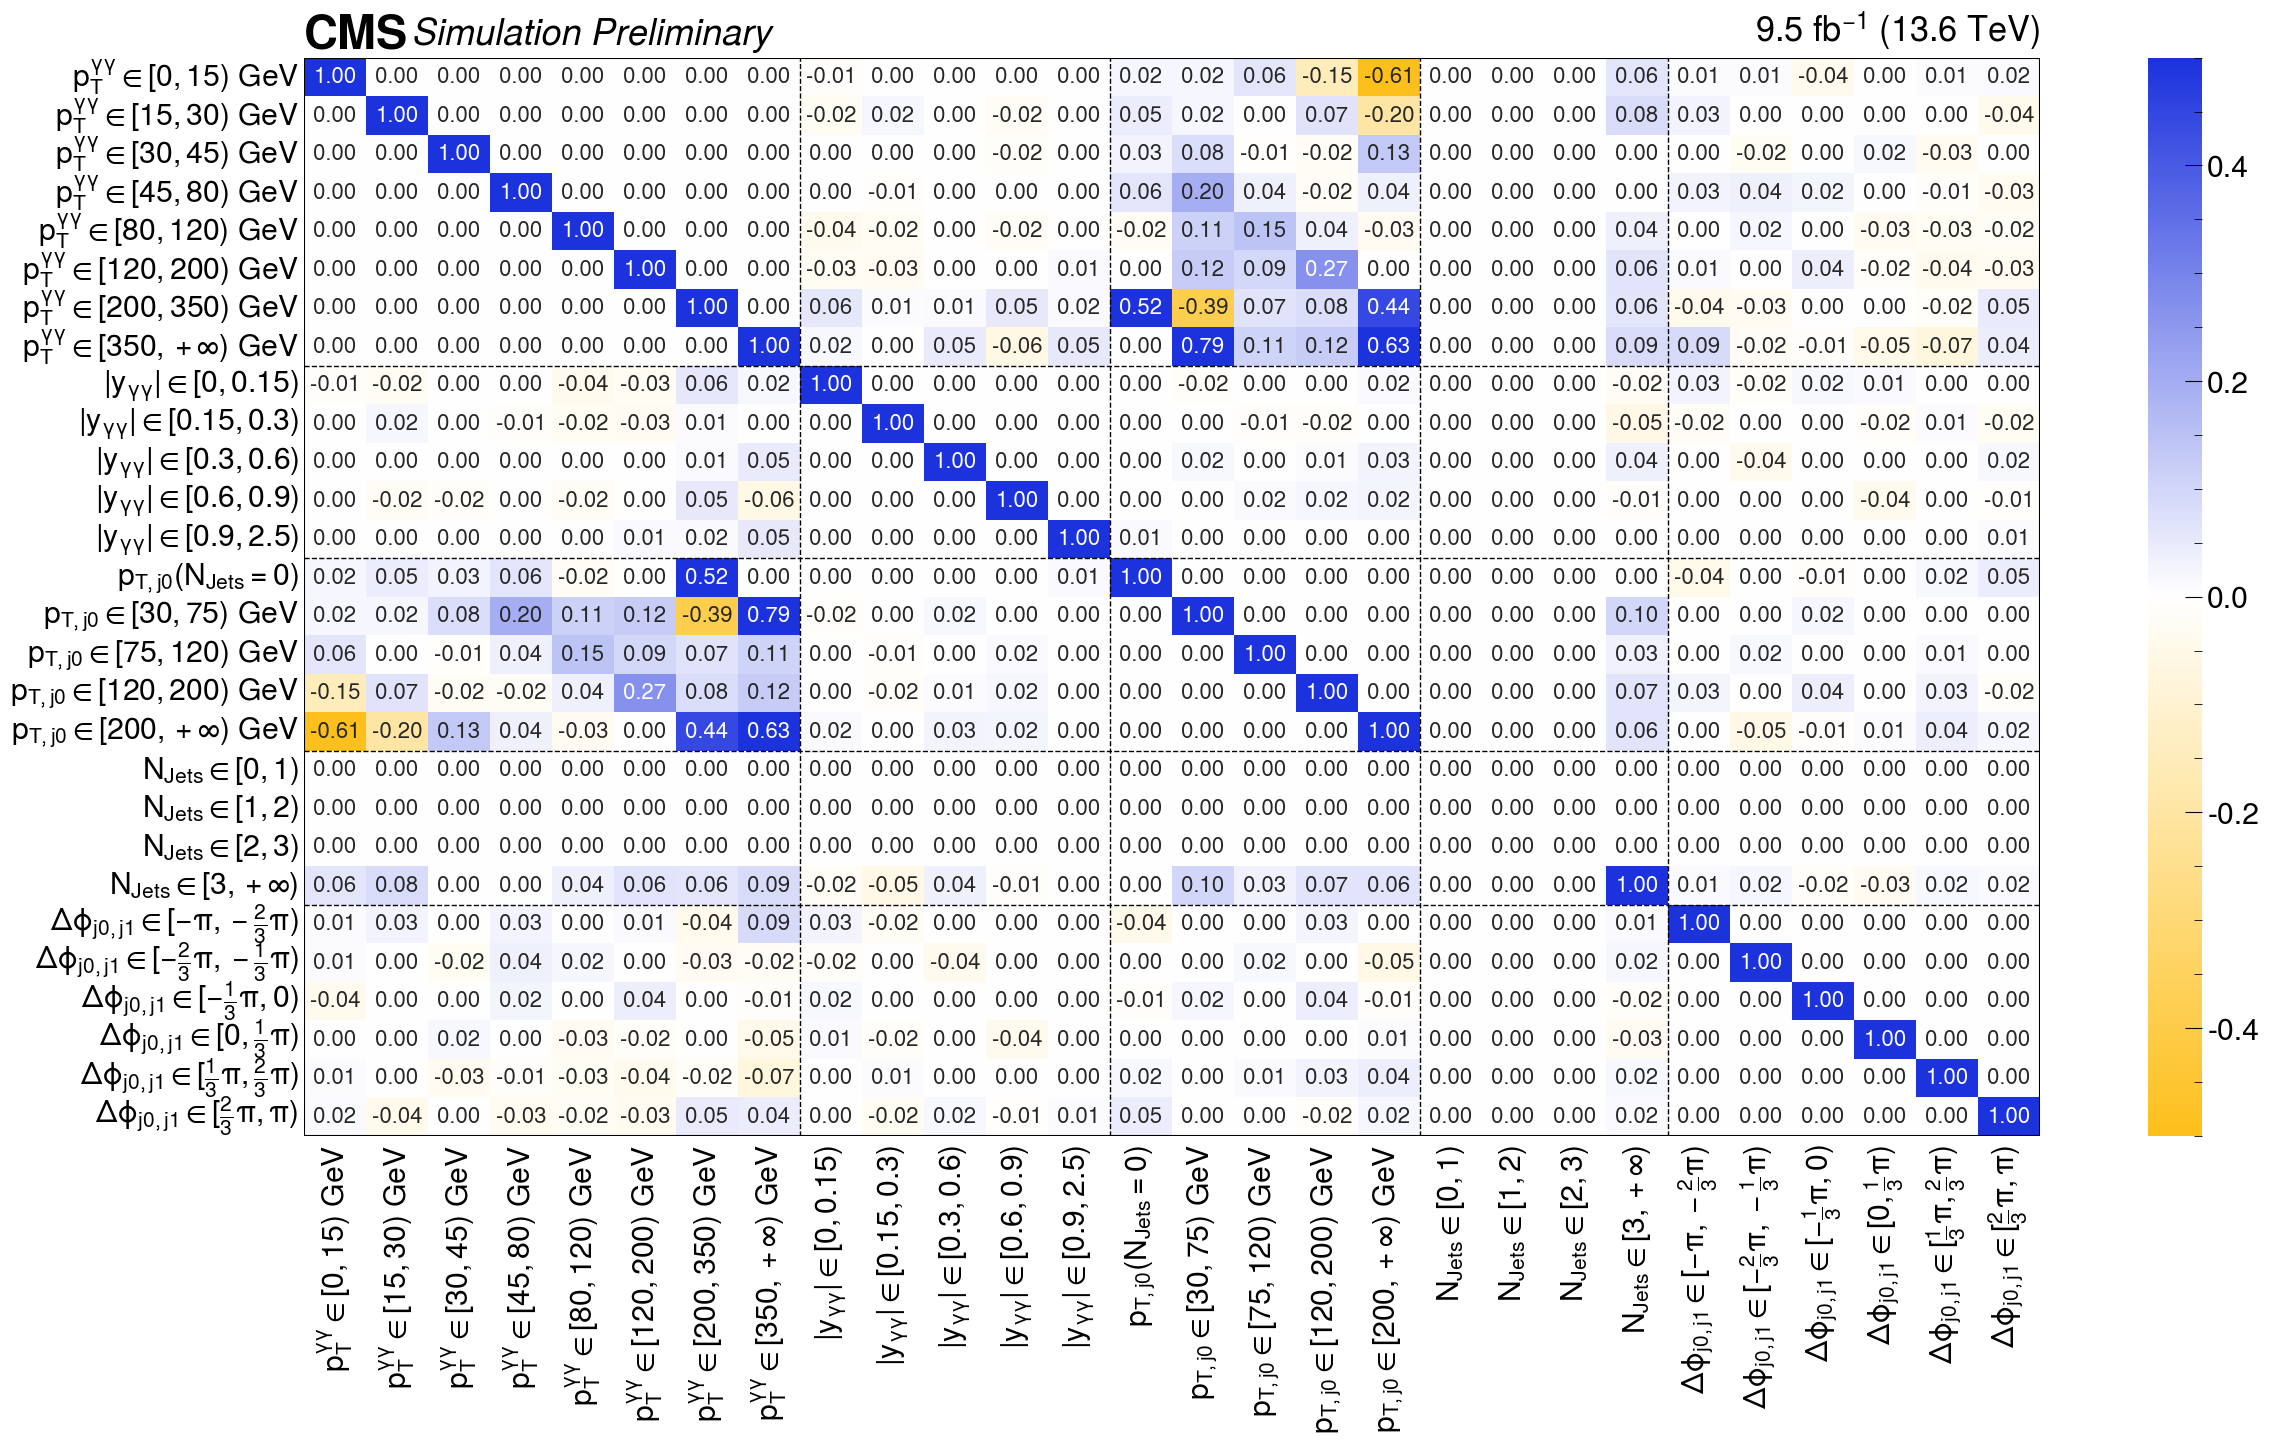

In [68]:

modified_corr_matrix = (corr_df).copy()
modified_corr_matrix = modified_corr_matrix.where(abs(modified_corr_matrix) >= 0.01, 0)  # Set values greater than 0.1 to 0

modified_corr_matrix = modified_corr_matrix.rename(index=translation, columns=translation)

plt.figure(figsize=(28, 14)) # 28, 14
plt.style.use(hep.style.CMS)
hep.cms.label('Preliminary', data=False, lumi=9.5, com=13.6)
ax = sns.heatmap(modified_corr_matrix, annot=True, cmap=custom_cmap, vmin=-0.5, vmax=0.5, annot_kws={"size": 16}, linewidths=0.0, linecolor='black', fmt=".2f")

ax.tick_params(
    axis='both',      # apply to both axes
    which='both',     # apply to both major and minor ticks
    bottom=False,     # remove bottom ticks
    top=False,        # remove top ticks
    left=False,       # remove left ticks
    right=False,      # remove right ticks
    labelbottom=True, # keep labels if you want
    labelleft=True    # keep labels if you want
)

# Get the number of rows and columns
n_rows, n_cols = modified_corr_matrix.shape

# Add rectangle around the whole heatmap to complete the outer box
rect = Rectangle(
    (0, 0),          # bottom left corner
    width=n_cols,    # number of columns
    height=n_rows,   # number of rows
    fill=False,      # no fill, just the edge
    edgecolor='black',
    linewidth=1.5
)
ax.add_patch(rect)

# Define group boundaries (between variable blocks)
group_boundaries = [8, 13, 18, 22]  # Example indices between variable blocks # 8, 14, 18, 23

# Draw thick lines between groups
for boundary in group_boundaries:
    ax.axhline(boundary, color='black', linewidth=1, linestyle='--')
    ax.axvline(boundary, color='black', linewidth=1, linestyle='--')

plt.savefig(os.path.join("/work/niharrin/t35/CMSSW_14_1_0_pre4/src/flashggFinalFit/Replicas/corr_matrix/corrMatrixDirectlyWithNTuples/", "correlation_matrix_powheg.pdf"), bbox_inches='tight')
plt.savefig(os.path.join("/work/niharrin/t35/CMSSW_14_1_0_pre4/src/flashggFinalFit/Replicas/corr_matrix/corrMatrixDirectlyWithNTuples/", "correlation_matrix_powheg.png"), bbox_inches='tight')

# plt.close()

In [384]:
madgraph_dfs[]
# kin_variables = ["PTH", "NJ", "rapidity"]
# from collections import defaultdict

# for kin_variable in kin_variables:
#     categories = list(madgraph_dfs[kin_variable].keys())
#     groups = defaultdict(list)

#     for item in categories:
#         # split into main part and cat part
#         prefix, cat = item.rsplit("_", 1)  
#         groups[prefix].append(item)

#     grouped_cats = list(groups.values())
    
#     for i, grouped_cat in enumerate(grouped_cats):
#         print(f"Group {i+1}: {grouped_cat}")
#         cols_to_merge = grouped_cat
#         cat_string = "_".join(grouped_cat[0].split("_")[:-1])
#          # New column name for the merged category
#         new_col = f"{cat_string}"
        
#         # OR across the three bins
#         membership_df[new_col] = membership_df[cols_to_merge].any(axis=1)

SyntaxError: invalid syntax (3651188376.py, line 1)

In [18]:
# 1️⃣ Define your stops and RGB values
stops = [0.0, 0.5, 1.0]
red   = [0.992, 1.0, 0.110]
green = [0.749, 1.0, 0.196]
blue  = [0.106, 1.0, 0.867]

# 2️⃣ Build the color dictionary
cdict = {
    'red':   [(stops[i], red[i], red[i]) for i in range(len(stops))],
    'green': [(stops[i], green[i], green[i]) for i in range(len(stops))],
    'blue':  [(stops[i], blue[i], blue[i]) for i in range(len(stops))]
}

# 3️⃣ Create the colormap
custom_cmap = LinearSegmentedColormap('gradient_8289', cdict)

ValueError: Must pass 2-d input. shape=(6, 18, 18)

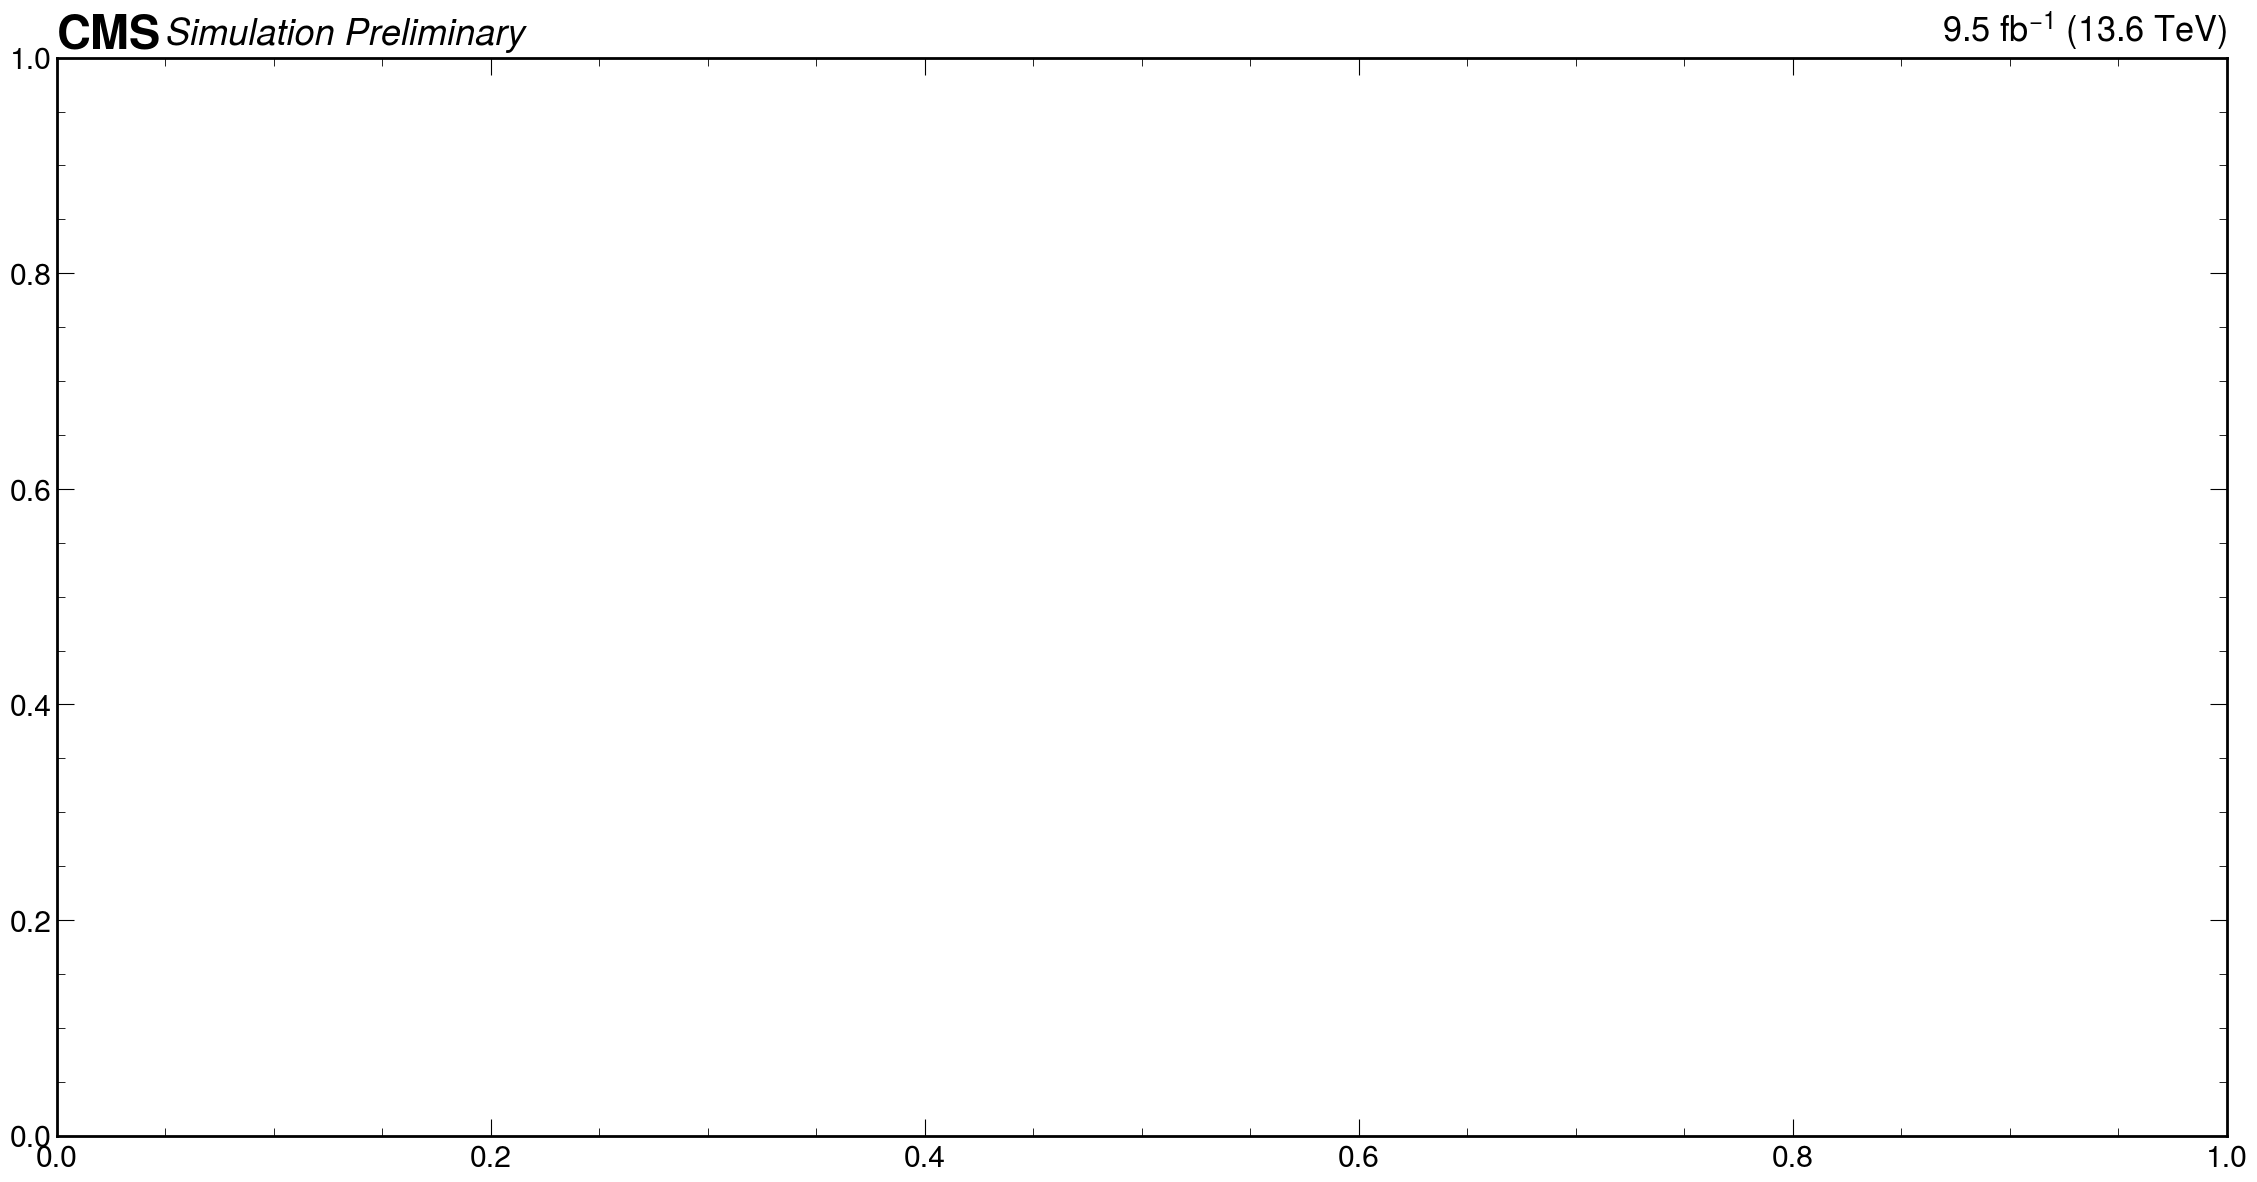

In [19]:
modified_corr_matrix = (correlation_matrices).copy()
# modified_corr_matrix = modified_corr_matrix.where(abs(modified_corr_matrix) >= 0.01, 0)  # Set values greater than 0.1 to 0

# modified_corr_matrix = modified_corr_matrix.rename(index=translation, columns=translation)

plt.figure(figsize=(28, 14)) # 28, 14
plt.style.use(hep.style.CMS)
hep.cms.label('Preliminary', data=False, lumi=9.5, com=13.6)
ax = sns.heatmap(modified_corr_matrix, annot=True, cmap=custom_cmap, vmin=-0.5, vmax=0.5, annot_kws={"size": 16}, linewidths=0.0, linecolor='black', fmt=".2f")

ax.tick_params(
    axis='both',      # apply to both axes
    which='both',     # apply to both major and minor ticks
    bottom=False,     # remove bottom ticks
    top=False,        # remove top ticks
    left=False,       # remove left ticks
    right=False,      # remove right ticks
    labelbottom=True, # keep labels if you want
    labelleft=True    # keep labels if you want
)

# Get the number of rows and columns
n_rows, n_cols = modified_corr_matrix.shape

# Add rectangle around the whole heatmap to complete the outer box
rect = Rectangle(
    (0, 0),          # bottom left corner
    width=n_cols,    # number of columns
    height=n_rows,   # number of rows
    fill=False,      # no fill, just the edge
    edgecolor='black',
    linewidth=1.5
)
ax.add_patch(rect)

# Define group boundaries (between variable blocks)
group_boundaries = [8, 12, 18, 23]  # Example indices between variable blocks # 8, 14, 18, 23

# Draw thick lines between groups
for boundary in group_boundaries:
    ax.axhline(boundary, color='black', linewidth=1, linestyle='--')
    ax.axvline(boundary, color='black', linewidth=1, linestyle='--')

plt.savefig(os.path.join("/work/niharrin/t35/CMSSW_14_1_0_pre4/src/flashggFinalFit/Replicas/corr_matrix/corrMatrixDirectlyWithNTuples/", "correlation_matrix_powheg.pdf"), bbox_inches='tight')
plt.savefig(os.path.join("/work/niharrin/t35/CMSSW_14_1_0_pre4/src/flashggFinalFit/Replicas/corr_matrix/corrMatrixDirectlyWithNTuples/", "correlation_matrix_powheg.png"), bbox_inches='tight')

# plt.close()


In [14]:
def plot_matrix(matrix, boundary, filename):
    plt.figure(figsize=(14, 8))
    plt.style.use(hep.style.CMS)
    hep.cms.label('Preliminary', data=False, lumi=9.5, com=13.6)
    ax = sns.heatmap(matrix, annot=True, cmap=custom_cmap, vmin=-0.5, vmax=0.5, annot_kws={"size": 16}, linewidths=0.0, linecolor='black', fmt=".2f")

    ax.tick_params(
        axis='both',      # apply to both axes
        which='both',     # apply to both major and minor ticks
        bottom=False,     # remove bottom ticks
        top=False,        # remove top ticks
        left=False,       # remove left ticks
        right=False,      # remove right ticks
        labelbottom=True, # keep labels if you want
        labelleft=True    # keep labels if you want
    )

    # Get the number of rows and columns
    n_rows, n_cols = matrix.shape

    # Add rectangle around the whole heatmap to complete the outer box
    rect = Rectangle(
        (0, 0),          # bottom left corner
        width=n_cols,    # number of columns
        height=n_rows,   # number of rows
        fill=False,      # no fill, just the edge
        edgecolor='black',
        linewidth=1.5
    )
    ax.add_patch(rect)

    # Draw thick lines between groups
    ax.axhline(boundary, color='black', linewidth=1, linestyle='--')
    ax.axvline(boundary, color='black', linewidth=1, linestyle='--')

    plt.savefig(os.path.join(plot_dir, f"{filename}.pdf"), bbox_inches='tight')
    plt.savefig(os.path.join(plot_dir, f"{filename}.png"), bbox_inches='tight')


In [ ]:
# df_combined = pd.concat([df_PTH_clean, df_DPhiJ0J1_clean, df_NJ_clean, df_PTJ0_clean, df_rapidity_clean], axis=1)

df_combined_dict = {
    "PTH": df_PTH_clean,
    "DPhiJ0J1": df_DPhiJ0J1_clean,
    "NJ": df_NJ_clean,
    "PTJ0": df_PTJ0_clean,
    "rapidity": df_rapidity_clean
}

variable_names = ["PTH", "DPhiJ0J1", "NJ", "PTJ0", "rapidity"]
variable_pairs = list(combinations(variable_names, 2))

# Define group boundaries (between variable blocks)
group_boundaries = {
    "PTH": 8,
    "DPhiJ0J1": 6,
    "NJ": 4,
    "PTJ0": 5,
    "rapidity": 5
}

for i, (variable1, variable2) in enumerate(variable_pairs):
    df_combined_reduced = pd.concat([df_combined_dict[variable1], df_combined_dict[variable2]], axis=1)
    matrix = df_combined_reduced.corr()
    modified_matrix = matrix.copy()
    modified_matrix = modified_matrix.where(abs(modified_matrix) >= 0.01, 0)  # Set values greater than 0.1 to 0
    modified_matrix = modified_matrix.rename(index=translation, columns=translation)
    boundary = group_boundaries[variable1]
    filename = f"correlation_matrix_{variable1}vs{variable2}"
    plot_matrix(modified_matrix, boundary, filename)


In [ ]:
z_hat = 0.5 * np.log((1 + corr_matrix) / (1 - corr_matrix)) + (corr_matrix / (2*(len(df_combined) - 2)))
a = np.tanh(z_hat - np.sqrt(1 / (len(df_combined) - 3)))
b = np.tanh(z_hat + np.sqrt(1 / (len(df_combined) - 3)))

In [ ]:
b - corr_matrix

In [ ]:
corr_matrix - a

In [ ]:
# From Wikipedia https://en.wikipedia.org/wiki/Pearson_correlation_coefficient
np.sqrt((1 - corr_matrix**2) / (len(df_combined) - 2))

In [ ]:
# Load combine toys
combineToy_dir = "/work/niharrin/t35/CMSSW_14_1_0_pre4/src/flashggFinalFit/Replicas/CombineToy_Validation/toys"
variable = "PTH"

pois_untrimmed_combineToys = create_json_untrimmed(variable, combineToy_dir, poi_list, extra_name="_combineToys")
pois_combineToys = create_json_trimmed(variable, combineToy_dir, pois_untrimmed_combineToys, poi_list, subfolder_=f"SL_{variable}", extra_name="_combineToys")

In [ ]:
df_combine = pd.DataFrame(pois_untrimmed_combineToys)
# --- Step 1: Identify rows WITHOUT -999 in either DataFrame ---
# Mask for df_PTH (True = valid, False = -999)
mask_combine = (df_combine != -999).all(axis=1)

# --- Step 2: Filter DataFrames ---
df_combine = df_combine[mask_combine]

# Calculate full correlation matrix
corr_matrix_combine = df_combine.corr()

In [ ]:
corr_matrix_combine
sns.heatmap(corr_matrix_combine, annot=True, cmap='coolwarm', vmin=-0.1, vmax=0.1)

In [ ]:
# z = 5

In [ ]:
# z = 1

In [ ]:
# z = 2

In [ ]:
# z = 4


In [ ]:
np.corrcoef(df_combine["r_PTH_15p0_30p0"], df_combine["r_PTH_350p0_10000p0"])[0,1]

In [ ]:
df_combine = pd.DataFrame(pois_combineToys)
# --- Step 1: Identify rows WITHOUT -999 in either DataFrame ---
# Mask for df_PTH (True = valid, False = -999)
mask_combine = (df_combine != -999).all(axis=1)

# --- Step 2: Filter DataFrames ---
df_combine = df_combine[mask_combine]

# Calculate full correlation matrix
corr_matrix_combine = df_combine.corr()
np.corrcoef(df_combine["r_PTH_15p0_30p0"], df_combine["r_PTH_350p0_10000p0"])[0,1]

In [ ]:
plot_all_individual_correlation(pois_untrimmed_combineToys, poi_list, variable)

In [ ]:
df_untrimmed_combine = pd.DataFrame(pois_untrimmed_combineToys)
# --- Step 1: Identify rows WITHOUT -999 in either DataFrame ---
# Mask for df_PTH (True = valid, False = -999)
mask_combine = (df_untrimmed_combine != -999).all(axis=1)

# --- Step 2: Filter DataFrames ---
df_untrimmed_combine = df_untrimmed_combine[mask_combine]

# Calculate full correlation matrix
corr_matrix_untrimmed_combine = df_untrimmed_combine.corr()

In [ ]:
plt.figure(figsize=(18, 8))
sns.heatmap(corr_matrix_untrimmed_combine, annot=True, cmap='coolwarm', vmin=-0.1, vmax=0.1)

In [ ]:
df_untrimmed_NJ = pd.DataFrame(pois_untrimmed_NJ)
df_untrimmed_PTJ0 = pd.DataFrame(pois_untrimmed_PTJ0)

In [ ]:
df_untrimmed_NJ

In [ ]:
df_untrimmed_PTJ0